# EDA: Predicting MDS-UPDRS from CSF Proteomics

**Competition:** AMP-PD Peptide (Parkinson's Disease Evolution Prediction)

**Objective:** Explore train data to understand structure, targets, and relationships relevant to predicting UPDRS scores (`updrs_1`–`updrs_4`) from protein/peptide abundance.

**Data available locally:**
- `train_clinical_data.csv` — UPDRS targets + medication flag
- `supplemental_clinical_data.csv` — clinical-only progression (no CSF)
- `train_proteins.csv` — protein-level NPX
- `train_peptides.csv` — peptide-level abundance

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("..").resolve()
DATA = ROOT / "data"
FIG = ROOT / "outputs" / "eda"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

clinical = pd.read_csv(DATA / "train_clinical_data.csv")
supp = pd.read_csv(DATA / "supplemental_clinical_data.csv")
proteins = pd.read_csv(DATA / "train_proteins.csv")
peptides = pd.read_csv(DATA / "train_peptides.csv")

updrs_cols = ["updrs_1", "updrs_2", "updrs_3", "updrs_4"]

## 1. Dataset overview

In [2]:
overview = pd.DataFrame(
    {
        "rows": [len(clinical), len(supp), len(proteins), len(peptides)],
        "patients": [
            clinical.patient_id.nunique(),
            supp.patient_id.nunique(),
            proteins.patient_id.nunique(),
            peptides.patient_id.nunique(),
        ],
        "unique_entities": [
            clinical.visit_id.nunique(),
            supp.visit_id.nunique(),
            proteins.UniProt.nunique(),
            peptides.Peptide.nunique(),
        ],
    },
    index=["clinical", "supplemental", "proteins", "peptides"],
)
overview

,rows,patients,unique_entities
clinical,2615,248,2615
supplemental,2223,771,2223
proteins,232741,248,227
peptides,981834,248,968


## 2. Target variables (UPDRS)

Each visit records four UPDRS sub-scores. Higher = more severe symptoms.

| Part | Domain |
|------|--------|
| updrs_1 | Non-motor experiences (mood, cognition) |
| updrs_2 | Motor experiences of daily living |
| updrs_3 | Motor examination (most medication-sensitive) |
| updrs_4 | Motor complications |

In [ ]:
missing = supp[updrs_cols + ["upd23b_clinical_state_on_medication"]].isnull().sum().to_frame("missing")
missing["pct"] = (100 * missing["missing"] / len(clinical)).round(1)
display(supp[updrs_cols].describe().T)
display(missing)

,count,mean,std,min,25%,50%,75%,max
updrs_1,2614.0,7.110559,5.525955,0.0,3.0,6.0,10.0,33.0
updrs_2,2613.0,6.743590,6.323230,0.0,1.0,5.0,10.0,40.0
updrs_3,2590.0,19.421236,15.000289,0.0,6.0,19.0,29.0,86.0
updrs_4,1577.0,1.861763,3.022112,0.0,0.0,0.0,3.0,20.0


,missing,pct
updrs_1,1,0.0
updrs_2,2,0.1
updrs_3,25,1.0
updrs_4,1038,39.7
upd23b_clinical_state_on_medication,1327,50.7


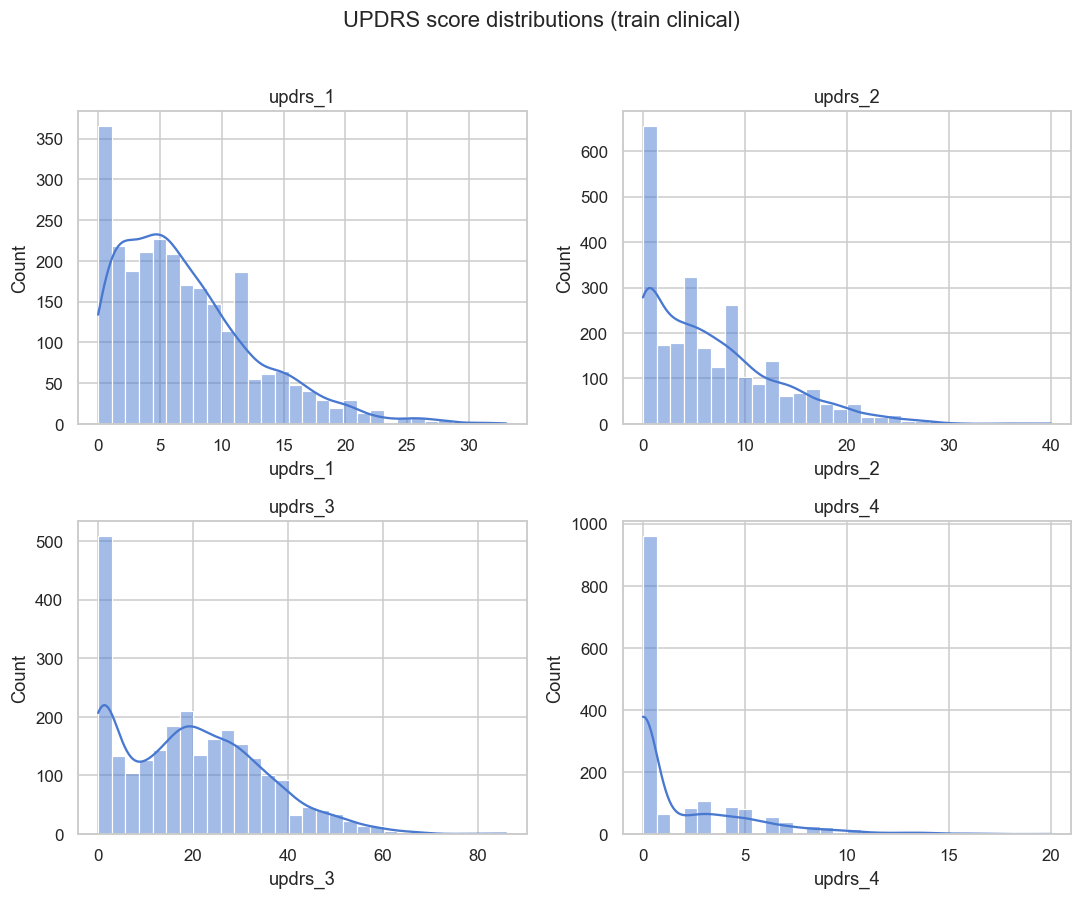

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), updrs_cols):
    sns.histplot(clinical[col].dropna(), bins=30, kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle("UPDRS score distributions (train clinical)", y=1.02)
plt.tight_layout()
plt.show()

## 3. Longitudinal structure

- **248 patients** in train clinical, ~10.5 visits each (3–17).
- Follow-up spans **0–108 months** from baseline.
- `visit_id` encodes `{patient_id}_{visit_month}`.
- Supplemental cohort: **771 patients**, zero overlap with train — useful for modeling progression without omics.

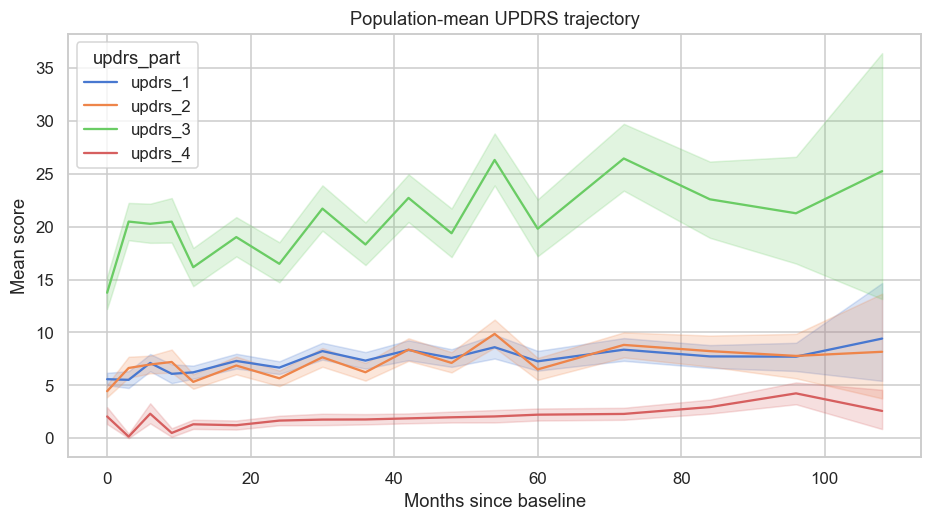

In [5]:
long_clin = clinical.melt(
    id_vars=["visit_month"],
    value_vars=updrs_cols,
    var_name="updrs_part",
    value_name="score",
)
plt.figure(figsize=(10, 5))
sns.lineplot(data=long_clin, x="visit_month", y="score", hue="updrs_part", errorbar=("ci", 95))
plt.title("Population-mean UPDRS trajectory")
plt.xlabel("Months since baseline")
plt.ylabel("Mean score")
plt.show()

## 4. Medication effect (critical for UPDRS-3)

`upd23b_clinical_state_on_medication` is **On/Off** for ~49% of visits; missing for the rest.

Motor scores are substantially **lower on medication** (better function), so this must be modeled explicitly.

                                          mean  median  count
upd23b_clinical_state_on_medication                          
Off                                  30.871345    30.0    513
On                                   24.368970    22.0    767


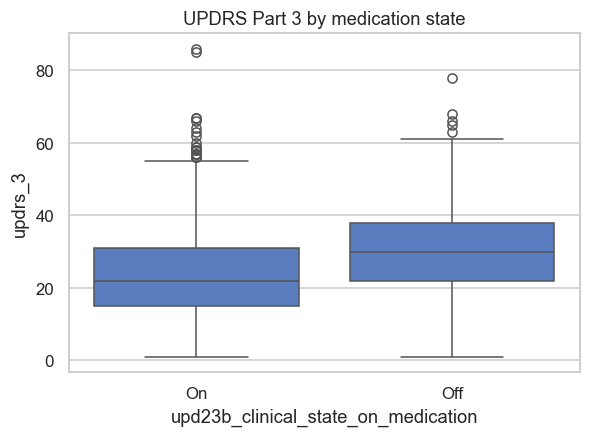

In [6]:
med = clinical.dropna(subset=["upd23b_clinical_state_on_medication", "updrs_3"])
print(med.groupby("upd23b_clinical_state_on_medication")["updrs_3"].agg(["mean", "median", "count"]))

plt.figure(figsize=(6, 4))
sns.boxplot(data=med, x="upd23b_clinical_state_on_medication", y="updrs_3")
plt.title("UPDRS Part 3 by medication state")
plt.show()

## 5. Omics ↔ clinical join coverage

Only **~41%** of clinical visits have CSF protein measurements. Most modeling rows will need either:
- predicting UPDRS only at visits with CSF, or
- using historical clinical visits + current proteins for forward prediction (time-series API pattern).

Visits with proteins: 1068 (40.8%)
Proteins per visit (median): 212.0


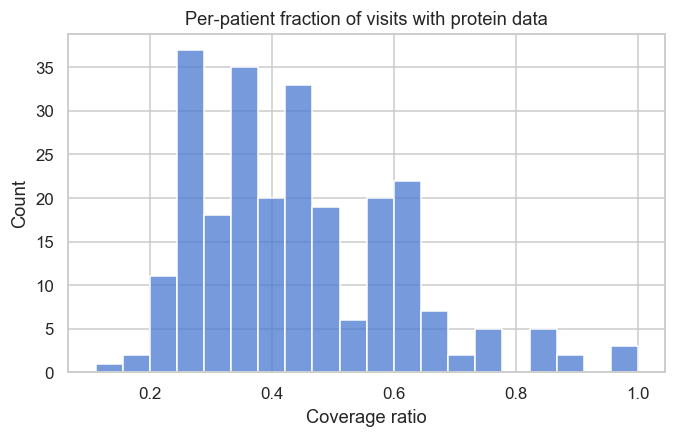

In [7]:
visit_flags = clinical[["visit_id", "patient_id"]].copy()
visit_flags["has_proteins"] = visit_flags["visit_id"].isin(proteins["visit_id"])

print("Visits with proteins:", visit_flags["has_proteins"].sum(), f"({100*visit_flags['has_proteins'].mean():.1f}%)")
print("Proteins per visit (median):", proteins.groupby("visit_id").size().median())

coverage = visit_flags.groupby("patient_id")["has_proteins"].mean()
plt.figure(figsize=(7, 4))
sns.histplot(coverage, bins=20)
plt.title("Per-patient fraction of visits with protein data")
plt.xlabel("Coverage ratio")
plt.show()

## 6. Protein signal vs UPDRS

227 proteins × 968 peptides. NPX spans orders of magnitude — log transforms recommended.

Univariate correlations are modest (|r| < 0.25) but suggest CSF proteomics carries predictive signal, especially for motor-related parts.

In [8]:
merged = proteins.merge(clinical[["visit_id"] + updrs_cols], on="visit_id", how="inner")
pivot = merged.pivot_table(index="visit_id", columns="UniProt", values="NPX", aggfunc="first")
targets = merged.drop_duplicates("visit_id").set_index("visit_id")[updrs_cols]

corrs = {}
for target in updrs_cols:
    y = targets[target]
    valid = y.notna()
    corrs[target] = pivot.loc[valid].apply(lambda s: s.corr(y.loc[valid]), axis=0)

corr_df = pd.DataFrame(corrs)
top = corr_df.abs().max(axis=1).sort_values(ascending=False).head(15).index
corr_df.loc[top].style.background_gradient(cmap="coolwarm", axis=None).format("{:.3f}")

,updrs_1,updrs_2,updrs_3,updrs_4
UniProt,,,,
O15240,-0.158,-0.214,-0.229,-0.013
Q06481,-0.203,-0.229,-0.201,-0.120
P13521,-0.142,-0.194,-0.223,-0.031
O00533,-0.145,-0.183,-0.222,-0.006
P04180,-0.182,-0.218,-0.161,-0.067
P05060,-0.182,-0.215,-0.206,-0.078
P43121,-0.159,-0.201,-0.187,-0.023
P17174,-0.176,-0.195,-0.188,-0.107
Q9BY67,-0.163,-0.195,-0.192,-0.046


## 7. Key takeaways for modeling UPDRS

1. **Multi-target:** Predict `updrs_1`–`updrs_4`; parts are correlated but measure different domains.
2. **Missing targets:** `updrs_4` missing ~40%; consider separate heads or masked loss.
3. **Medication:** Strong confounder for `updrs_3` — encode `upd23b_clinical_state_on_medication` or predict off-medication motor scores.
4. **Sparse omics alignment:** Build patient-time panels; use supplemental clinical data for progression priors.
5. **Feature engineering:** Log(NPX), patient baselines, visit_month, lagged UPDRS, protein ratios.
6. **Time-series API:** Test delivery is grouped by patient visit batches — validate with `public_timeseries_testing_util.py`.
7. **Peptides vs proteins:** Peptides are finer-grained (968 features) but proteins (227) are already aggregated and easier to start with.